# NLP Preprocessing Practice

**목표**
1. 샘플 텍스트 데이터를 데이터프레임으로 구성하기
2. 정규표현식을 이용해 텍스트를 정제하기
3. 토큰화 결과를 생성하기
4. 영어 텍스트에서 stemming과 lemmatization 결과를 확인하기
5. 한국어 텍스트에서 형태소 분석 결과를 생성하기
6. 전처리 함수를 만들어 여러 문장에 일괄 적용하기
7. 전처리 결과를 바탕으로 단어 빈도를 집계하고 시각화하기

## 0. 실습 환경 준비

In [100]:
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.stem import PorterStemmer, WordNetLemmatizer

from konlpy.tag import Okt
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## 1. 샘플 데이터프레임 만들기

1. 아래의 샘플 데이터를 이용해 `df` 데이터프레임을 생성하기
2. 컬럼명은 `id`, `lang`, `category`, `text` 로 설정하기
3. `df.head()` 와 `df.shape` 를 출력하기

In [101]:
sample_rows = [
    (1, 'ko', 'review', '배송이 정말 빨랐고 포장도 깔끔했습니다. 제품 상태가 좋아서 만족합니다.'),
    (2, 'ko', 'review', '배송 안내가 정확하고 포장이 꼼꼼해서 받자마자 만족했습니다. 재구매 의사 있습니다.'),
    (3, 'ko', 'review', '화면이 선명하고 배터리가 오래가서 업무용으로 쓰기 좋았습니다. 성능도 안정적입니다.'),
    (4, 'ko', 'review', '화면은 예쁘지만 버튼 위치가 불편해서 처음 사용할 때 조금 헷갈렸습니다.'),
    (5, 'ko', 'review', '가격 대비 품질이 좋고 사용 방법도 쉬워서 가족에게 추천하고 싶습니다.'),
    (6, 'ko', 'support', '문의는 help@shopnow.kr 로 보내주세요. 주문번호 10482 관련 배송 상태를 확인하고 싶습니다.'),
    (7, 'ko', 'promotion', '[광고] 이번 주말 한정 할인 진행 중입니다. 신규 회원은 무료 배송 쿠폰도 받을 수 있습니다.'),
    (8, 'en', 'review', 'The delivery was fast and the packaging was neat, so I was happy with the purchase.'),
    (9, 'en', 'review', 'The screen looks sharp and the battery lasts long enough for daily work.'),
    (10, 'en', 'support', 'Contact us at support@techbox.io or visit https://techbox.io/help for order support.'),
    (11, 'en', 'promotion', 'Limited time sale now on. New members can get a free shipping coupon today.'),
    (12, 'en', 'review', 'The button layout felt awkward at first, but the overall design was still clean.')
]

df = pd.DataFrame(sample_rows, columns=['id', 'lang', 'category', 'text'])
display(df.head())
print(df.shape)

,id,lang,category,text
0,1,ko,review,배송이 정말 빨랐고 포장도 깔끔했습니다. 제품 상태가 좋아서 만족합니다.
1,2,ko,review,배송 안내가 정확하고 포장이 꼼꼼해서 받자마자 만족했습니다. 재구매 의사 있습니다.
2,3,ko,review,화면이 선명하고 배터리가 오래가서 업무용으로 쓰기 좋았습니다. 성능도 안정적입니다.
3,4,ko,review,화면은 예쁘지만 버튼 위치가 불편해서 처음 사용할 때 조금 헷갈렸습니다.
4,5,ko,review,가격 대비 품질이 좋고 사용 방법도 쉬워서 가족에게 추천하고 싶습니다.


(12, 4)


## 2. 텍스트 길이와 언어별 개수 확인하기

1. 문자 수 기준 텍스트 길이를 저장하는 `text_len` 컬럼 만들기
2. `lang` 별 데이터 개수 집계하기
3. `category` 별 데이터 개수 집계하기
4. `id`, `lang`, `category`, `text_len` 컬럼만 확인하기

In [102]:
# 여기에 코드를 작성하세요.
df['text_len'] = df['text'].str.len()

print('lang counts:', Counter(df['lang']))
print('category counts:', Counter(df['category']))

display(df[['id', 'lang', 'category', 'text_len']])

lang counts: Counter({'ko': 7, 'en': 5})
category counts: Counter({'review': 8, 'support': 2, 'promotion': 2})


,id,lang,category,text_len
0,1,ko,review,40
1,2,ko,review,46
2,3,ko,review,46
3,4,ko,review,40
4,5,ko,review,39
5,6,ko,support,60
6,7,ko,promotion,53
7,8,en,review,83
8,9,en,review,72
9,10,en,support,84


## 3. 정규표현식으로 텍스트 정제하기

1. 원본 `text` 컬럼을 바탕으로 `clean_text` 컬럼 만들기
2. URL 제거하기
3. 이메일 제거하기
4. 숫자 제거하기
5. 한글, 영문, 공백을 제외한 특수문자 제거하기
6. 연속된 공백을 한 칸으로 정리하고 양끝 공백 제거하기
7. `text`, `clean_text` 두 컬럼을 함께 출력하기

In [103]:
def clean_text_fn(text):
    text = re.sub(r'https\S+', '', text)        # URL 제거
    text = re.sub(r'\S+@\S+', '', text)         # 이메일 제거
    text = re.sub(r'[0-9]', '', text)           # 숫자 제거
    text = re.sub(r'[^\s\w]', '', text)         # 특수문자 제거
    text = re.sub(r'\s+', ' ', text).strip()    # 공백 정리
    return text

df['clean_text'] = df['text'].apply(clean_text_fn)

display(df[['text', 'clean_text']])

,text,clean_text
0,배송이 정말 빨랐고 포장도 깔끔했습니다. 제품 상태가 좋아서 만족합니다.,배송이 정말 빨랐고 포장도 깔끔했습니다 제품 상태가 좋아서 만족합니다
1,배송 안내가 정확하고 포장이 꼼꼼해서 받자마자 만족했습니다. 재구매 의사 있습니다.,배송 안내가 정확하고 포장이 꼼꼼해서 받자마자 만족했습니다 재구매 의사 있습니다
2,화면이 선명하고 배터리가 오래가서 업무용으로 쓰기 좋았습니다. 성능도 안정적입니다.,화면이 선명하고 배터리가 오래가서 업무용으로 쓰기 좋았습니다 성능도 안정적입니다
3,화면은 예쁘지만 버튼 위치가 불편해서 처음 사용할 때 조금 헷갈렸습니다.,화면은 예쁘지만 버튼 위치가 불편해서 처음 사용할 때 조금 헷갈렸습니다
4,가격 대비 품질이 좋고 사용 방법도 쉬워서 가족에게 추천하고 싶습니다.,가격 대비 품질이 좋고 사용 방법도 쉬워서 가족에게 추천하고 싶습니다
5,문의는 help@shopnow.kr 로 보내주세요. 주문번호 10482 관련 배송 ...,문의는 로 보내주세요 주문번호 관련 배송 상태를 확인하고 싶습니다
6,[광고] 이번 주말 한정 할인 진행 중입니다. 신규 회원은 무료 배송 쿠폰도 받을 ...,광고 이번 주말 한정 할인 진행 중입니다 신규 회원은 무료 배송 쿠폰도 받을 수 있습니다
7,The delivery was fast and the packaging was ne...,The delivery was fast and the packaging was ne...
8,The screen looks sharp and the battery lasts l...,The screen looks sharp and the battery lasts l...
9,Contact us at support@techbox.io or visit http...,Contact us at or visit for order support


## 4. 영어 텍스트 토큰화하기

1. `lang` 가 `en` 인 데이터만 모아 `df_en` 데이터프레임 만들기
2. `clean_text` 컬럼을 기준으로 `word_tokenize` 결과를 `tokens_word` 컬럼에 저장하기
3. `RegexpTokenizer(r'[A-Za-z]+')` 결과를 `tokens_regex` 컬럼에 저장하기
4. `id`, `clean_text`, `tokens_word`, `tokens_regex` 컬럼을 출력하기

In [104]:
# 여기에 코드를 작성하세요.
df_en = df[df['lang'] == 'en'].copy()

df_en['tokens_word'] = df_en['clean_text'].apply(word_tokenize)

regex_tokenizer = RegexpTokenizer(r'[A-Za-z]+')
df_en['tokens_regex'] = df_en['clean_text'].apply(regex_tokenizer.tokenize)

display(df_en[['id', 'clean_text', 'tokens_word', 'tokens_regex']])

,id,clean_text,tokens_word,tokens_regex
7,8,The delivery was fast and the packaging was ne...,"[The, delivery, was, fast, and, the, packaging...","[The, delivery, was, fast, and, the, packaging..."
8,9,The screen looks sharp and the battery lasts l...,"[The, screen, looks, sharp, and, the, battery,...","[The, screen, looks, sharp, and, the, battery,..."
9,10,Contact us at or visit for order support,"[Contact, us, at, or, visit, for, order, support]","[Contact, us, at, or, visit, for, order, support]"
10,11,Limited time sale now on New members can get a...,"[Limited, time, sale, now, on, New, members, c...","[Limited, time, sale, now, on, New, members, c..."
11,12,The button layout felt awkward at first but th...,"[The, button, layout, felt, awkward, at, first...","[The, button, layout, felt, awkward, at, first..."


## 5. 영어 텍스트 stemming과 lemmatization 적용하기

1. `PorterStemmer` 객체를 생성하기
2. `WordNetLemmatizer` 객체를 생성하기
3. `tokens_regex` 컬럼을 기준으로 stemming 결과를 `stemmed_tokens` 컬럼에 저장하기
4. 같은 컬럼을 기준으로 lemmatization 결과를 `lemmatized_tokens` 컬럼에 저장하기
5. `id`, `tokens_regex`, `stemmed_tokens`, `lemmatized_tokens` 컬럼을 출력하기

In [105]:
# 여기에 코드를 작성하세요.
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

df_en['stemmed_tokens'] = df_en['tokens_regex'].apply(
    lambda tokens: [stemmer.stem(token) for token in tokens]
)

df_en['lemmatized_tokens'] = df_en['tokens_regex'].apply(
    lambda tokens: [lemmatizer.lemmatize(token) for token in tokens]
)

display(df_en[['id', 'tokens_regex', 'stemmed_tokens', 'lemmatized_tokens']])

,id,tokens_regex,stemmed_tokens,lemmatized_tokens
7,8,"[The, delivery, was, fast, and, the, packaging...","[the, deliveri, wa, fast, and, the, packag, wa...","[The, delivery, wa, fast, and, the, packaging,..."
8,9,"[The, screen, looks, sharp, and, the, battery,...","[the, screen, look, sharp, and, the, batteri, ...","[The, screen, look, sharp, and, the, battery, ..."
9,10,"[Contact, us, at, or, visit, for, order, support]","[contact, us, at, or, visit, for, order, support]","[Contact, u, at, or, visit, for, order, support]"
10,11,"[Limited, time, sale, now, on, New, members, c...","[limit, time, sale, now, on, new, member, can,...","[Limited, time, sale, now, on, New, member, ca..."
11,12,"[The, button, layout, felt, awkward, at, first...","[the, button, layout, felt, awkward, at, first...","[The, button, layout, felt, awkward, at, first..."


## 6. 한국어 텍스트 형태소 분석하기

1. `lang` 가 `ko` 인 데이터만 모아 `df_ko` 데이터프레임 만들기
2. `Okt` 객체를 생성하기
3. `clean_text` 컬럼을 기준으로 형태소 분석 결과를 `morphs` 컬럼에 저장하기
4. 같은 컬럼을 기준으로 명사 추출 결과를 `nouns` 컬럼에 저장하기
5. `id`, `clean_text`, `morphs`, `nouns` 컬럼을 출력하기

In [106]:
# 여기에 코드를 작성하세요.
df_ko = df[df['lang'] == 'ko'].copy()

okt = Okt()

df_ko['morphs'] = df_ko['clean_text'].apply(okt.morphs)
df_ko['nouns'] = df_ko['clean_text'].apply(okt.nouns)

display(df_ko[['id', 'clean_text', 'morphs', 'nouns']])

,id,clean_text,morphs,nouns
0,1,배송이 정말 빨랐고 포장도 깔끔했습니다 제품 상태가 좋아서 만족합니다,"[배송, 이, 정말, 빨랐고, 포장, 도, 깔끔했습니다, 제품, 상태, 가, 좋아서...","[배송, 정말, 포장, 제품, 상태]"
1,2,배송 안내가 정확하고 포장이 꼼꼼해서 받자마자 만족했습니다 재구매 의사 있습니다,"[배송, 안내, 가, 정확하고, 포장, 이, 꼼꼼해서, 받자마자, 만족했습니다, 재...","[배송, 안내, 포장, 의사]"
2,3,화면이 선명하고 배터리가 오래가서 업무용으로 쓰기 좋았습니다 성능도 안정적입니다,"[화면, 이, 선명하고, 배터리, 가, 오래, 가서, 업무, 용, 으로, 쓰기, 좋...","[화면, 배터리, 업무, 용, 쓰기, 성능, 안정]"
3,4,화면은 예쁘지만 버튼 위치가 불편해서 처음 사용할 때 조금 헷갈렸습니다,"[화면, 은, 예쁘지만, 버튼, 위치, 가, 불편해서, 처음, 사용, 할, 때, 조...","[화면, 버튼, 위치, 처음, 사용, 때, 조금]"
4,5,가격 대비 품질이 좋고 사용 방법도 쉬워서 가족에게 추천하고 싶습니다,"[가격, 대비, 품질, 이, 좋고, 사용, 방법, 도, 쉬워서, 가족, 에게, 추천...","[가격, 대비, 품질, 사용, 방법, 가족, 추천]"
5,6,문의는 로 보내주세요 주문번호 관련 배송 상태를 확인하고 싶습니다,"[문의, 는, 로, 보내주세요, 주문, 번호, 관련, 배송, 상태, 를, 확인, 하...","[문의, 로, 주문, 번호, 관련, 배송, 상태, 확인]"
6,7,광고 이번 주말 한정 할인 진행 중입니다 신규 회원은 무료 배송 쿠폰도 받을 수 있습니다,"[광고, 이번, 주말, 한정, 할인, 진행, 중, 입니다, 신규, 회원, 은, 무료...","[광고, 이번, 주말, 한정, 할인, 진행, 중, 신규, 회원, 무료, 배송, 쿠폰..."


## 7. 한국어 전처리 함수 만들기

1. `preprocess_korean(text)` 함수를 정의하기
2. 함수 안에서 `clean_text_fn()` 으로 정제하기
3. `okt.morphs()` 로 토큰화하기
4. 불용어 제거하기
5. 길이가 1인 토큰 제거하기
6. 최종 토큰 리스트를 반환하기
7. `df_ko` 의 `processed_tokens` 컬럼에 적용한 뒤 `id`, `processed_tokens` 컬럼을 출력하기

In [107]:
ko_stopwords = [
    '은', '는', '이', '가', '을', '를', '에', '의', '도', '로', '과', '와',
    '에서', '으로', '하다', '있다', '입니다', '합니다', '그리고', '하지만',
    '정말', '조금', '이번', '주말', '관련', '싶습니다', '있습니다', '하고'
]

def preprocess_korean(text):
    text = clean_text_fn(text)
    tokens = okt.morphs(text)

    tokens = [
        token for token in tokens
        if token not in ko_stopwords and len(token) > 1
    ]

    return tokens

df_ko['processed_tokens'] = df_ko['text'].apply(preprocess_korean)

display(df_ko[['id', 'processed_tokens']])

,id,processed_tokens
0,1,"[배송, 빨랐고, 포장, 깔끔했습니다, 제품, 상태, 좋아서, 만족합니다]"
1,2,"[배송, 안내, 정확하고, 포장, 꼼꼼해서, 받자마자, 만족했습니다, 재구매, 의사]"
2,3,"[화면, 선명하고, 배터리, 오래, 가서, 업무, 쓰기, 좋았습니다, 성능, 안정]"
3,4,"[화면, 예쁘지만, 버튼, 위치, 불편해서, 처음, 사용, 헷갈렸습니다]"
4,5,"[가격, 대비, 품질, 좋고, 사용, 방법, 쉬워서, 가족, 에게, 추천]"
5,6,"[문의, 보내주세요, 주문, 번호, 배송, 상태, 확인]"
6,7,"[광고, 한정, 할인, 진행, 신규, 회원, 무료, 배송, 쿠폰, 받을]"


## 8. 단어 빈도 집계하기

1. `df_ko['processed_tokens']` 의 모든 토큰을 하나의 리스트로 합치기
2. `Counter` 를 사용해 단어 빈도수를 계산하기
3. 가장 많이 등장한 단어 10개를 `top10_words` 변수에 저장하기
4. `top10_words` 를 출력하기

In [108]:
all_tokens = sum(df_ko['processed_tokens'], [])

word_counter = Counter(all_tokens)
top10_words = word_counter.most_common(10)

print('Top 10 words:', top10_words)

Top 10 words: [('배송', 4), ('포장', 2), ('상태', 2), ('화면', 2), ('사용', 2), ('빨랐고', 1), ('깔끔했습니다', 1), ('제품', 1), ('좋아서', 1), ('만족합니다', 1)]


## 9. 상위 단어 막대그래프 그리기

1. `top10_words` 를 이용해 단어와 빈도 리스트를 분리하기
2. matplotlib 으로 막대그래프 그리기
3. 그래프 제목은 `Top 10 Korean Tokens`

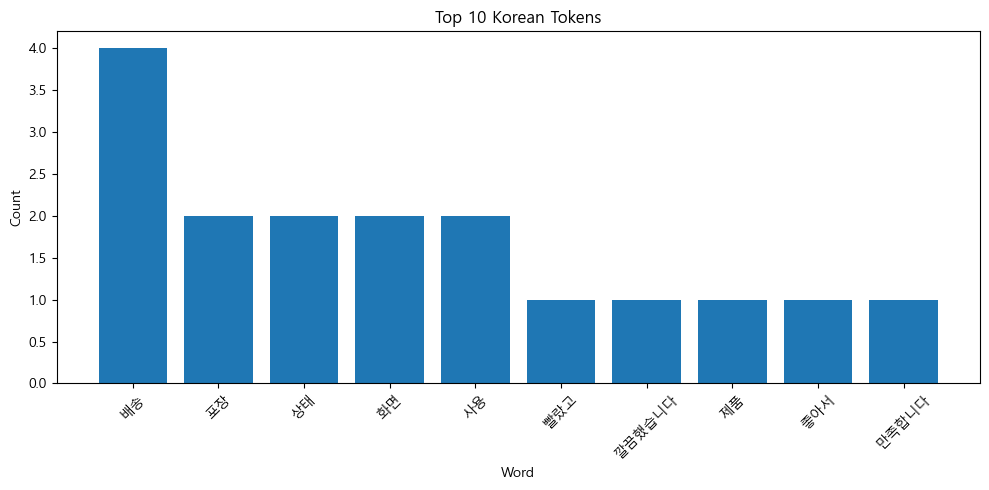

In [109]:
words = [word for word, count in top10_words]
counts = [count for word, count in top10_words]

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title('Top 10 Korean Tokens')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. 워드클라우드 생성하기

1. `top10_words` 또는 전체 `word_counter` 를 사용해 워드클라우드 생성하기
2. 이미지를 출력하기

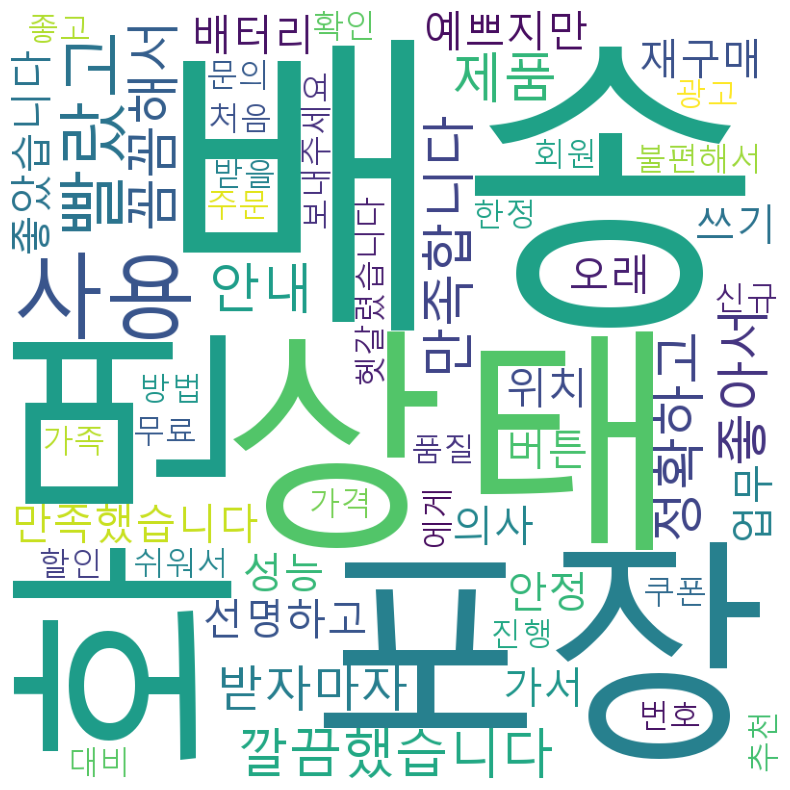

In [110]:
# 여기에 코드를 작성하세요.
filtered_words = {
    word: count
    for word, count in word_counter.items()
    if word not in ko_stopwords and len(word) > 1
}

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    font_path='C:\\Windows\\Fonts\\malgun.ttf'
).generate_from_frequencies(filtered_words)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()